# Lecture 7 — Fully Connected Networks, Optimization, Initialization

**CMU 10-414/714, Deep Learning Systems**
Companion notebook · Sangram Lembe

With autodiff available, a fully connected network is a short forward definition. That frees the
lecture to ask the two questions that decide whether a network trains at all:

1. **which update rule** — gradient descent, momentum, Nesterov, Adam, and why not Newton
2. **which starting point** — why zero fails, and why the variance of a random initialisation
   decides between vanishing, stable and exploding activations

Every claim below is run, not quoted. The optimizers are compared on a quadratic where the
behaviour is visible, then on a real network where it matters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.random.seed(0)
digits = load_digits()
X_all, y_all = digits.data / 16.0, digits.target.astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=0, stratify=y_all)
m, n = X_train.shape
k = int(y_all.max() + 1)

def softmax_rows(z):
    e = np.exp(z - z.max(1, keepdims=True))
    return e / e.sum(1, keepdims=True)

def one_hot(y, k):
    I = np.zeros((y.size, k)); I[np.arange(y.size), y] = 1
    return I

def cross_entropy(logits, y):
    mx = logits.max(1, keepdims=True)
    lse = mx[:, 0] + np.log(np.exp(logits - mx).sum(1))
    return float(np.mean(lse - logits[np.arange(y.size), y]))

print(f"n = {n}, k = {k}, m = {m}")

n = 64, k = 10, m = 1347


## 1. The network, now with biases

$$Z_1 = X, \qquad Z_{i+1} = \sigma_i\left(Z_i W_i + \mathbf{1} b_i^{\mathsf{T}}\right), \qquad h_\theta(X) = Z_{L+1}$$

Biases were dropped in lecture 3 only because they were one more term to differentiate by hand.
The shapes: $W_i$ is $n_i \times n_{i+1}$ and $b_i$ has length $n_{i+1}$ — sized to the layer's
**output**.

$Z_iW_i$ is $m \times n_{i+1}$ and $b_i$ is a vector, so the sum needs $\mathbf{1}b_i^{\mathsf{T}}$:
a matrix of $m$ identical rows. Frameworks never build it; they **broadcast**.

In [2]:
m_demo, n_out = 4, 3
b = np.array([10.0, 20.0, 30.0])
ZW = np.arange(12, dtype=float).reshape(m_demo, n_out)

explicit  = ZW + np.ones((m_demo, 1)) @ b.reshape(1, n_out)   # 1 b^T, materialised
broadcast = ZW + b.reshape(1, n_out)                          # singleton axis, repeated virtually

print("identical results:", np.allclose(explicit, broadcast))
print("explicit form stores", (np.ones((m_demo, 1)) @ b.reshape(1, n_out)).size,
      "numbers for a bias of length", b.size)

identical results: True
explicit form stores 12 numbers for a bias of length 3


### The part that is actually hard: differentiating through a broadcast

If the forward pass copies one row into $m$ rows, every copy influences the loss, so the gradient
flowing back to $b$ must **sum** the gradient over those $m$ rows. Broadcasting forward is
summation backward. That claim is easy to check against finite differences.

In [3]:
def mlp_forward(X, Ws, bs):
    """Returns the cached layers Z and pre-activations A."""
    Z, A = [X], []
    for i, (W, b) in enumerate(zip(Ws, bs)):
        a = Z[-1] @ W + b                         # broadcasting adds the bias
        A.append(a)
        Z.append(np.maximum(0, a) if i < len(Ws) - 1 else a)
    return Z, A

def mlp_backward(Z, A, Ws, y):
    """Gradients for every W and b."""
    G = (softmax_rows(Z[-1]) - one_hot(y, k)) / y.size
    dWs, dbs = [None] * len(Ws), [None] * len(Ws)
    for i in reversed(range(len(Ws))):
        D = G if i == len(Ws) - 1 else G * (A[i] > 0)
        dWs[i] = Z[i].T @ D
        dbs[i] = D.sum(axis=0)                    # <- broadcast forward, SUM backward
        G = D @ Ws[i].T
    return dWs, dbs

def mlp_loss(X, y, Ws, bs):
    return cross_entropy(mlp_forward(X, Ws, bs)[0][-1], y)

rng = np.random.default_rng(0)
Xs, ys = X_train[:12], y_train[:12]
Ws = [rng.normal(0, .3, (n, 9)), rng.normal(0, .3, (9, k))]
bs = [rng.normal(0, .3, 9), rng.normal(0, .3, k)]

Z, A = mlp_forward(Xs, Ws, bs)
dWs, dbs = mlp_backward(Z, A, Ws, ys)

eps = 1e-6
for li in range(2):
    num = np.zeros_like(bs[li])
    for j in range(bs[li].size):
        bs[li][j] += eps; a = mlp_loss(Xs, ys, Ws, bs)
        bs[li][j] -= 2*eps; c = mlp_loss(Xs, ys, Ws, bs)
        bs[li][j] += eps
        num[j] = (a - c) / (2*eps)
    print(f"bias {li+1}: max |sum-rule gradient - numeric| = {np.abs(dbs[li]-num).max():.2e}")

bias 1: max |sum-rule gradient - numeric| = 2.31e-10
bias 2: max |sum-rule gradient - numeric| = 4.43e-10


## 2. Optimizers, on a problem where you can see them

Take the quadratic $f(\theta) = \tfrac12 \theta^{\mathsf{T}} P \theta$ with $P = \mathrm{diag}(0.5, 5)$:
shallow in one direction, steep in the other. The gradient points across the valley rather than
along it, which is exactly the failure the lecture describes.

In [4]:
P = np.diag([0.5, 5.0])
f    = lambda t: 0.5 * t @ P @ t
grad = lambda t: P @ t
start = np.array([3.0, 0.85])

def run(update, steps=60):
    t, state, path = start.copy(), {}, [start.copy()]
    for i in range(steps):
        t = update(t, state, i)
        path.append(t.copy())
    return np.array(path)

def gd(alpha):
    return lambda t, s, i: t - alpha * grad(t)

def momentum(alpha, beta, unbias=False):
    def step(t, s, i):
        s["u"] = beta * s.get("u", 0) + (1 - beta) * grad(t)
        u = s["u"] / (1 - beta**(i + 1)) if unbias else s["u"]
        return t - alpha * u
    return step

def nesterov(alpha, beta):
    def step(t, s, i):
        u = s.get("u", np.zeros(2))
        s["u"] = beta * u + (1 - beta) * grad(t - alpha * beta * u)   # look ahead
        return t - alpha * s["u"]
    return step

def adam(alpha, b1=0.9, b2=0.999, eps=1e-8):
    def step(t, s, i):
        g = grad(t)
        s["u"] = b1 * s.get("u", 0) + (1 - b1) * g
        s["v"] = b2 * s.get("v", 0) + (1 - b2) * g**2
        u_hat = s["u"] / (1 - b1**(i + 1))
        v_hat = s["v"] / (1 - b2**(i + 1))
        return t - alpha * u_hat / (np.sqrt(v_hat) + eps)
    return step

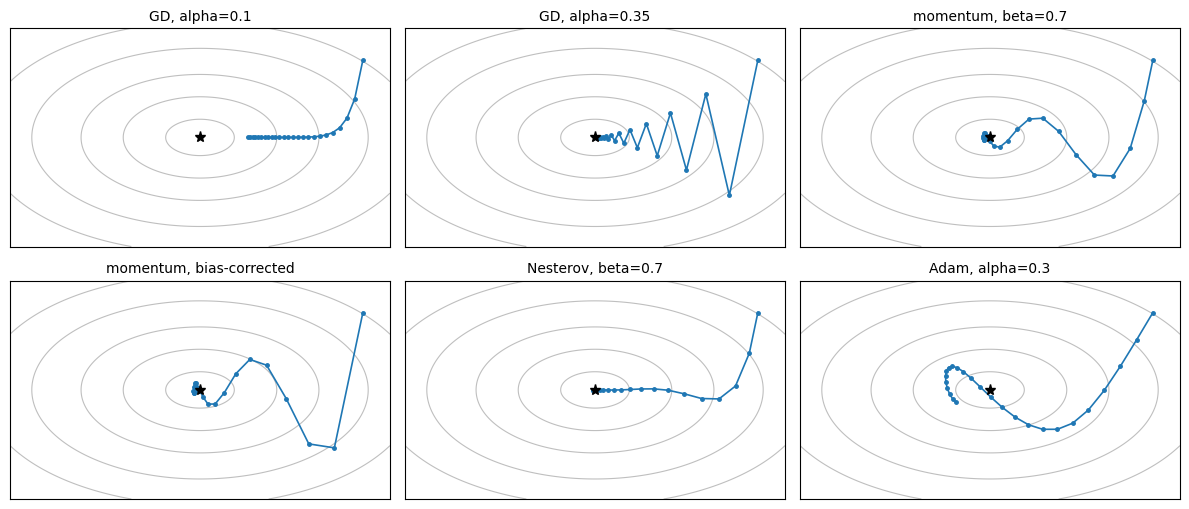

In [5]:
runs = {
    "GD, alpha=0.1":             run(gd(0.1)),
    "GD, alpha=0.35":            run(gd(0.35)),
    "momentum, beta=0.7":        run(momentum(0.35, 0.7)),
    "momentum, bias-corrected":  run(momentum(0.35, 0.7, unbias=True)),
    "Nesterov, beta=0.7":        run(nesterov(0.35, 0.7)),
    "Adam, alpha=0.3":           run(adam(0.3)),
}

xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 200), np.linspace(-1.2, 1.2, 200))
ff = 0.5 * (0.5 * xx**2 + 5 * yy**2)

fig, axes = plt.subplots(2, 3, figsize=(12, 5.2))
for ax, (name, path) in zip(axes.ravel(), runs.items()):
    ax.contour(xx, yy, ff, levels=[0.1, 0.5, 1.2, 2.4, 4], colors="0.75", linewidths=0.8)
    ax.plot(path[:25, 0], path[:25, 1], "o-", ms=2.5, lw=1.2)
    ax.plot(0, 0, "k*", ms=8)
    ax.set_title(name, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

In [6]:
def steps_to(path, tol=1e-4):
    vals = [f(t) for t in path]
    hit = [i for i, v in enumerate(vals) if v < tol]
    return hit[0] if hit else None

print(f"{'optimizer':<28}{'steps to f < 1e-4':>20}")
print("-" * 48)
for name, path in runs.items():
    s = steps_to(path)
    print(f"{name:<28}{('not reached' if s is None else s):>20}")

optimizer                      steps to f < 1e-4
------------------------------------------------
GD, alpha=0.1                        not reached
GD, alpha=0.35                                27
momentum, beta=0.7                            29
momentum, bias-corrected                      26
Nesterov, beta=0.7                            16
Adam, alpha=0.3                      not reached


Read the table with the lecture's warning in mind: a convex quadratic is where these methods are
*easiest to see*, not where their ranking is decided. Deep networks are non-convex and far from
quadratic. The point of this section is the shape of the trajectories — the zigzag, the smoothing,
the rescaling — not a leaderboard.

Adam's "not reached" is informative rather than a failure. Dividing by $\sqrt{v}$ makes its step
roughly $\alpha$ in every coordinate regardless of gradient size, so with a fixed $\alpha$ it
closes in quickly and then hovers at a distance on the order of $\alpha$ instead of settling.
That is why Adam is normally paired with a decaying learning rate.

### Newton's method, and why nobody uses it

Scaling the gradient by the inverse Hessian points straight at the optimum. On a quadratic the
Hessian is exactly $P$, so a full Newton step lands on the minimum in **one** iteration.

In [7]:
H = P                                            # the Hessian of this quadratic
newton = start - np.linalg.solve(H, grad(start)) # full step, alpha = 1
print("after ONE Newton step:", newton, "  f =", f(newton))

print(f"\n{'parameters':>16}{'Hessian entries':>20}{'float32 storage':>18}")
print("-" * 54)
for p in [1e4, 1e6, 1e8, 1e9]:
    entries = p * p
    print(f"{p:>16,.0f}{entries:>20.1e}{entries*4/1e12:>15.1e} TB")

after ONE Newton step: [0. 0.]   f = 0.0

      parameters     Hessian entries   float32 storage
------------------------------------------------------
          10,000             1.0e+08        4.0e-04 TB
       1,000,000             1.0e+12        4.0e+00 TB
     100,000,000             1.0e+16        4.0e+04 TB
   1,000,000,000             1.0e+18        4.0e+06 TB


The Hessian is parameters-by-parameters. At a billion parameters it would take four million
terabytes just to store — before inverting it. It is also awkward to make stochastic, and for a
non-convex objective the Newton direction is not obviously the one you want. Every other method in
this notebook tries to get some of Newton's direction-correction at first-order cost.

## 3. Everything is stochastic

The optimizers above were shown with full gradients. In practice every gradient is a minibatch
estimate. The argument for that is about **work done**, so measure progress against the number of
examples processed rather than the number of updates.

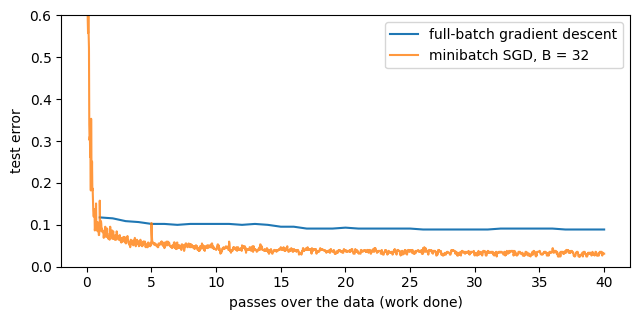

 passes   full batch   SGD, B=32
--------------------------------
      1        0.118       0.109
      2        0.116       0.067
      5        0.102       0.049
     10        0.102       0.044
     20        0.093       0.040
     40        0.089       0.033


In [8]:
def train_softmax(batch, epochs, lr):
    theta = np.zeros((n, k))
    seen, curve = 0, []
    for _ in range(epochs):
        order = np.random.permutation(m)
        for i in range(0, m, batch):
            idx = order[i:i+batch]
            Xb, yb = X_train[idx], y_train[idx]
            theta -= lr * Xb.T @ (softmax_rows(Xb @ theta) - one_hot(yb, k)) / yb.size
            seen += yb.size
            curve.append((seen, float((np.argmax(X_test @ theta, 1) != y_test).mean())))
    return np.array(curve)

np.random.seed(0)
full = train_softmax(batch=m,  epochs=40, lr=0.5)     # classic gradient descent
sgd  = train_softmax(batch=32, epochs=40, lr=0.5)     # minibatch SGD

plt.figure(figsize=(6.5, 3.3))
plt.plot(full[:, 0] / m, full[:, 1], label="full-batch gradient descent")
plt.plot(sgd[:, 0]  / m, sgd[:, 1],  label="minibatch SGD, B = 32", alpha=0.8)
plt.xlabel("passes over the data (work done)"); plt.ylabel("test error")
plt.ylim(0, 0.6); plt.legend(); plt.tight_layout(); plt.show()

print(f"{'passes':>7}{'full batch':>13}{'SGD, B=32':>12}")
print("-" * 32)
for p in (1, 2, 5, 10, 20, 40):
    fi = min(len(full) - 1, p - 1)
    si = min(len(sgd) - 1, int(p * m / 32) - 1)
    print(f"{p:>7}{full[fi, 1]:>13.3f}{sgd[si, 1]:>12.3f}")

After one pass over the data, full-batch gradient descent has made **one** update and SGD has made
about forty. At that first mark the two are roughly level — single SGD steps are noisy — but from
the second pass on SGD is clearly ahead, and after forty passes it has about a third of the error.
Same work, many more updates.

## 4. Initialisation: zero is a trap

In convex optimisation, starting at zero is standard. In a network with more than one layer it is
fatal: every activation is zero, so every gradient is zero, so nothing ever updates.

In [9]:
Ws0 = [np.zeros((n, 32)), np.zeros((32, k))]
bs0 = [np.zeros(32), np.zeros(k)]
Z, A = mlp_forward(X_train[:64], Ws0, bs0)
dWs, dbs = mlp_backward(Z, A, Ws0, y_train[:64])

for i, (dW, db) in enumerate(zip(dWs, dbs)):
    print(f"layer {i+1}: max |dW| = {np.abs(dW).max():.3g}   max |db| = {np.abs(db).max():.3g}")

layer 1: max |dW| = 0   max |db| = 0
layer 2: max |dW| = 0   max |db| = 0.0562


Every weight gradient is exactly zero. The final bias does receive a gradient — the softmax of
all-zero logits is uniform, not one-hot — but the hidden layer's weights never do, so the hidden
units stay identical to each other forever. All-zeros is a fixed point of the part of the update
that matters.

### Random, but the variance is the whole story

Sample weights from $\mathcal{N}(0, \sigma^2)$ and push an input through 50 ReLU layers of width
784 — the lecture's MNIST setting — measuring the activation norm at every layer.

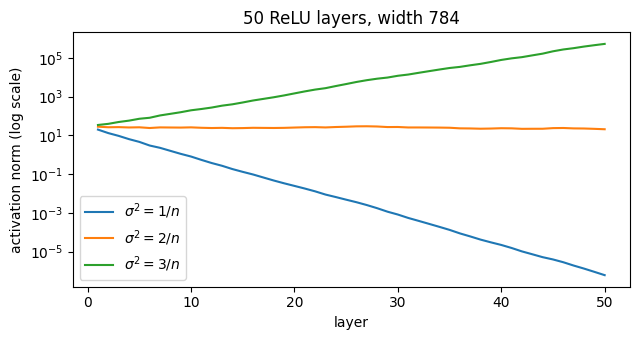

sigma^2 = 1/n :  layer 1      19.8   layer 50  6.16e-07
sigma^2 = 2/n :  layer 1        28   layer 50      20.7
sigma^2 = 3/n :  layer 1      34.3   layer 50  5.22e+05


In [10]:
def activation_norms(c, depth=50, width=784, seed=0):
    rng = np.random.default_rng(seed)
    z = rng.normal(size=(1, width))
    norms = []
    for _ in range(depth):
        W = rng.normal(0, np.sqrt(c / width), (width, width))
        z = np.maximum(0, z @ W)
        norms.append(np.linalg.norm(z))
    return np.array(norms)

curves = {c: activation_norms(c) for c in (1.0, 2.0, 3.0)}

plt.figure(figsize=(6.5, 3.5))
for c, nm in curves.items():
    plt.semilogy(range(1, 51), nm, label=fr"$\sigma^2 = {int(c)}/n$")
plt.xlabel("layer"); plt.ylabel("activation norm (log scale)"); plt.legend()
plt.title("50 ReLU layers, width 784"); plt.tight_layout(); plt.show()

for c, nm in curves.items():
    print(f"sigma^2 = {int(c)}/n :  layer 1 {nm[0]:9.3g}   layer 50 {nm[-1]:9.3g}")

Three variances differing by a constant factor produce collapse, stability and explosion across
about eleven orders of magnitude.

### Why exactly $2/n$

With input coordinates of variance 1 and independent weights of variance $1/n$, one product
$x_iw_i$ has variance $1/n$, and an inner product sums $n$ independent such terms — variances add —
giving $n \cdot \tfrac1n = 1$. So $1/n$ preserves variance through a **linear** layer. A ReLU zeroes
roughly half the entries and halves the second moment, so $2/n$ is what compensates. Both halves
of that argument can be checked directly.

In [11]:
rng = np.random.default_rng(1)
width, trials = 784, 4000
x = rng.normal(size=(trials, width))
W = rng.normal(0, np.sqrt(1 / width), (width, 256))

pre = x @ W                                         # linear layer, sigma^2 = 1/n
print(f"linear layer with 1/n  : variance of output = {pre.var():.3f}   (predicted 1)")

post = np.maximum(0, pre)
print(f"after ReLU             : E[z^2]              = {(post**2).mean():.3f}   (predicted 0.5)")

W2 = rng.normal(0, np.sqrt(2 / width), (width, 256))
post2 = np.maximum(0, x @ W2)
print(f"ReLU layer with 2/n    : E[z^2]              = {(post2**2).mean():.3f}   (predicted 1)")

linear layer with 1/n  : variance of output = 0.996   (predicted 1)
after ReLU             : E[z^2]              = 0.497   (predicted 0.5)
ReLU layer with 2/n    : E[z^2]              = 0.999   (predicted 1)


## 5. Weights do not move far

The lecture's most unsettling claim: during training, parameters stay close to where they
started, and the difference between two initialisations can outweigh the movement optimisation
produces. That is measurable. Train the same network twice from two different random seeds and
compare how far each moved against how far apart they end up.

In [12]:
def kaiming(sizes, seed):
    r = np.random.default_rng(seed)
    Ws = [r.normal(0, np.sqrt(2 / a), (a, b)) for a, b in zip(sizes[:-1], sizes[1:])]
    bs = [np.zeros(b) for b in sizes[1:]]
    return Ws, bs

def train_mlp(Ws, bs, lr=0.1, B=64, epochs=40, seed=0):
    r = np.random.default_rng(seed)
    Ws, bs = [W.copy() for W in Ws], [b.copy() for b in bs]
    for _ in range(epochs):
        order = r.permutation(m)
        for i in range(0, m, B):
            idx = order[i:i+B]
            Z, A = mlp_forward(X_train[idx], Ws, bs)
            dWs, dbs = mlp_backward(Z, A, Ws, y_train[idx])
            for j in range(len(Ws)):
                Ws[j] -= lr * dWs[j]; bs[j] -= lr * dbs[j]
    return Ws, bs

sizes = [n, 128, 128, k]
W0a, b0a = kaiming(sizes, seed=1)
W0b, b0b = kaiming(sizes, seed=2)
WTa, bTa = train_mlp(W0a, b0a)
WTb, bTb = train_mlp(W0b, b0b)

err = lambda Ws, bs: float((np.argmax(mlp_forward(X_test, Ws, bs)[0][-1], 1) != y_test).mean())
print(f"run A test error {err(WTa, bTa):.4f}    run B test error {err(WTb, bTb):.4f}\n")

fro = np.linalg.norm
print(f"{'layer':>6}{'moved / initial':>18}{'A vs B at the end / moved':>28}")
print("-" * 52)
for i in range(len(sizes) - 1):
    moved = fro(WTa[i] - W0a[i])
    print(f"{i+1:>6}{moved / fro(W0a[i]):>18.3f}{fro(WTa[i] - WTb[i]) / moved:>28.1f}")

run A test error 0.0200    run B test error 0.0244

 layer   moved / initial   A vs B at the end / moved
----------------------------------------------------
     1             0.240                         6.2
     2             0.241                         6.2
     3             0.870                         2.5


Both runs reach essentially the same test error. But each layer's weights moved only a fraction of
their initial size, and the two trained networks are several times further from *each other* than
either is from its own starting point. They found equally good solutions in different places,
each near where it began.

The convex-optimisation intuition — the start washes out because everything converges to the same
point — does not hold. Initialisation largely decides which region training explores.

## 6. The optimizers on a real network

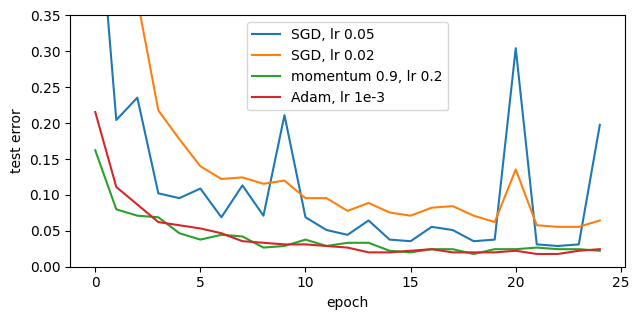

optimizer                   best   final   worst after epoch 5
--------------------------------------------------------------
SGD, lr 0.05               0.029   0.198                 0.304
SGD, lr 0.02               0.056   0.064                 0.140
momentum 0.9, lr 0.2       0.018   0.022                 0.044
Adam, lr 1e-3              0.018   0.024                 0.053


In [13]:
def train_with(opt, lr, epochs=25, B=64, seed=0):
    r = np.random.default_rng(seed)
    Ws, bs = kaiming(sizes, seed=3)
    params = Ws + bs
    state = [dict() for _ in params]
    curve = []
    t = 0
    for _ in range(epochs):
        order = r.permutation(m)
        for i in range(0, m, B):
            idx = order[i:i+B]
            Z, A = mlp_forward(X_train[idx], Ws, bs)
            dWs, dbs = mlp_backward(Z, A, Ws, y_train[idx])
            for p, g, s in zip(params, dWs + dbs, state):
                if opt == "sgd":
                    p -= lr * g
                elif opt == "momentum":
                    s["u"] = 0.9 * s.get("u", 0) + 0.1 * g
                    p -= lr * s["u"]
                elif opt == "adam":
                    s["u"] = 0.9 * s.get("u", 0) + 0.1 * g
                    s["v"] = 0.999 * s.get("v", 0) + 0.001 * g**2
                    p -= lr * (s["u"] / (1 - 0.9**(t+1))) / (np.sqrt(s["v"] / (1 - 0.999**(t+1))) + 1e-8)
            t += 1
        curve.append(err(Ws, bs))
    return curve

results = {"SGD, lr 0.05": train_with("sgd", 0.05),
           "SGD, lr 0.02": train_with("sgd", 0.02),
           "momentum 0.9, lr 0.2": train_with("momentum", 0.2),
           "Adam, lr 1e-3": train_with("adam", 1e-3)}

plt.figure(figsize=(6.5, 3.3))
for name, c in results.items():
    plt.plot(c, label=name)
plt.xlabel("epoch"); plt.ylabel("test error"); plt.ylim(0, 0.35); plt.legend()
plt.tight_layout(); plt.show()
print(f"{'optimizer':<24}{'best':>8}{'final':>8}{'worst after epoch 5':>22}")
print("-" * 62)
for name, c in results.items():
    print(f"{name:<24}{min(c):>8.3f}{c[-1]:>8.3f}{max(c[5:]):>22.3f}")

This is the most useful result in the notebook, and it was not the one I expected. Plain SGD at
lr 0.05 reaches under 3% error and then spikes back up — the "worst after epoch 5" column — while
at lr 0.02 it is stable but slower. Momentum and Adam train stably and end lower.

That is exactly the lecture's framing of practical optimisation: the goal is less about the
fastest possible convergence and more about reaching a good point *without careful step-size
tuning*. Averaging gradients (momentum) and rescaling them (Adam) both make the update less
sensitive to any single noisy minibatch. SGD with momentum and Adam are the two optimizers worth
knowing well; which wins is an empirical question for each architecture.

## Summary

- Biases are free once autodiff exists. Adding one is broadcasting, and its gradient is a **sum** over the broadcast axis — verified above.
- Momentum is an exponential moving average of gradients; Nesterov evaluates the gradient at the look-ahead point; Adam also divides by a running root-mean-square, elementwise.
- Newton solves a quadratic in one step and is unusable at scale: the Hessian is parameters × parameters.
- For the same work, many noisy minibatch steps beat one exact full-batch step.
- Zero initialisation gives zero weight gradients. For ReLU, $\sigma^2 = 2/n$ is stable; $1/n$ vanishes and $3/n$ explodes.
- Weights stay near their initialisation, and two runs end far apart from each other while performing equally well.